In [ ]:
!pip install pandas
!pip install nltk
!pip install scikit-learn
!pip install matplotlib seaborn

import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Bidirectional,
                                     Dropout, SpatialDropout1D, BatchNormalization,
                                     Conv1D, MaxPooling1D, GlobalMaxPooling1D)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to C:\Users\ASUS
[nltk_data]     TUF\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\ASUS
[nltk_data]     TUF\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\ASUS
[nltk_data]     TUF\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
### Load Data ###
df = pd.read_csv('IMDB Dataset.csv')

In [ ]:
# Drop NaN values
df = df.dropna()
print(f"Dataset shape: {df.shape}")
print(f"Class distribution:\n{df['sentiment'].value_counts()}")

Dataset shape: (50000, 2)
Class distribution:
negative    25000
positive    25000
Name: sentiment, dtype: int64


In [ ]:
# Create custom stop words list (excluding negations)
stop_words = set(stopwords.words('english'))
# Remove negation words from stop words
negation_words = {'not', 'no', 'nor', 'neither', 'never', 'none', 'nobody',
                  'nothing', 'nowhere', 'hardly', 'scarcely', 'barely', "don't",
                  "doesn't", "didn't", "won't", "wouldn't", "can't", "couldn't",
                  "shouldn't", "isn't", "aren't", "wasn't", "weren't"}
stop_words = stop_words - negation_words

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Enhanced preprocessing function"""
    # Remove HTML tags
    text = re.sub('<.*?>', ' ', text)

    # Handle common contractions
    contractions = {
        "won't": "will not", "can't": "cannot", "n't": " not",
        "'re": " are", "'ve": " have", "'ll": " will",
        "'d": " would", "'m": " am"
    }
    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)

    # Keep important punctuation for sentiment
    text = text.replace('!', ' exclaimation ')
    text = text.replace('?', ' question ')

    # Remove special characters but keep letters and spaces
    text = re.sub('[^a-zA-Z]', ' ', text)

    # Convert to lowercase
    text = text.lower()

    # Tokenize
    words = text.split()

    # Remove stop words and apply lemmatization
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words and len(word) > 2]

    return ' '.join(words)


In [ ]:
corpus = []
for i in tqdm(range(len(df)), desc="Processing reviews"):
    processed_text = preprocess_text(df['review'].iloc[i])
    corpus.append(processed_text)

Processing reviews: 100%|██████████| 50000/50000 [00:20<00:00, 2473.47it/s]


In [ ]:
# Use Tokenizer instead of one_hot for better control
vocab_size = 20000  # Increased vocabulary size
tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(corpus)

# Convert texts to sequences
sequences = tokenizer.texts_to_sequences(corpus)

# Analyze sequence lengths to determine optimal max_length
seq_lengths = [len(seq) for seq in sequences]
print(f"Average sequence length: {np.mean(seq_lengths):.2f}")
print(f"95th percentile: {np.percentile(seq_lengths, 95):.0f}")
print(f"Max sequence length: {max(seq_lengths)}")

# Use 95th percentile as max_length
max_length = int(np.percentile(seq_lengths, 95))
print(f"Using max_length: {max_length}")

# Pad sequences
x_padded = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')

# Prepare labels
y = df['sentiment'].map({'positive': 1, 'negative': 0}).values

print(f"Padded data shape: {x_padded.shape}")
print(f"Labels shape: {y.shape}")


Average sequence length: 120.99
95th percentile: 311
Max sequence length: 1433
Using max_length: 311
Padded data shape: (50000, 311)
Labels shape: (50000,)


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x_padded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {x_train.shape}, {y_train.shape}")
print(f"Test set: {x_test.shape}, {y_test.shape}")
print(f"Training class distribution: {np.bincount(y_train)}")

Training set: (40000, 311), (40000,)
Test set: (10000, 311), (10000,)
Training class distribution: [20000 20000]


In [ ]:
def create_model(vocab_size, embedding_dim, max_length):
    """Create an improved Bi-LSTM model with multiple enhancements"""
    model = Sequential([
        # Embedding layer
        Embedding(input_dim=vocab_size,
                 output_dim=embedding_dim,
                 input_length=max_length,
                 mask_zero=True),

        # Spatial Dropout for embedding layer
        SpatialDropout1D(0.3),

        # First Bi-LSTM layer with return sequences
        Bidirectional(LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)),
        BatchNormalization(),

        # Second Bi-LSTM layer
        Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.2)),
        BatchNormalization(),

        # Dense layers with regularization
        Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.5),

        Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.5),

        # Output layer
        Dense(1, activation='sigmoid')
    ])

    return model

# Create model
embedding_dim = 128
model = create_model(vocab_size, embedding_dim, max_length)

# Compile with custom learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)
model.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print(model.summary())

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 311, 128)          2560000   
_________________________________________________________________
spatial_dropout1d (SpatialDr (None, 311, 128)          0         
_________________________________________________________________
bidirectional (Bidirectional (None, 311, 256)          263168    
_________________________________________________________________
batch_normalization (BatchNo (None, 311, 256)          1024      
_________________________________________________________________
bidirectional_1 (Bidirection (None, 128)               164352    
_________________________________________________________________
batch_normalization_1 (Batch (None, 128)               512       
_________________________________________________________________
dense (Dense)                (None, 64)                8

In [ ]:

# Early stopping with more patience
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Learning rate reduction
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Model checkpoint to save best model
checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks = [early_stop, reduce_lr, checkpoint]

In [ ]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=20,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Train on 40000 samples, validate on 10000 samples
Epoch 1/20
39936/40000 [============================>.] - ETA: 2s - loss: 0.9379 - accuracy: 0.7515 - auc: 0.8323
Epoch 00001: val_accuracy improved from -inf to 0.82430, saving model to best_model.keras
40000/40000 [==============================] - 1852s 46ms/sample - loss: 0.9375 - accuracy: 0.7515 - auc: 0.8323 - val_loss: 0.5298 - val_accuracy: 0.8243 - val_auc: 0.9154
Epoch 2/20
39936/40000 [============================>.] - ETA: 2s - loss: 0.3445 - accuracy: 0.8817 - auc: 0.9437
Epoch 00002: val_accuracy improved from 0.82430 to 0.87000, saving model to best_model.keras
40000/40000 [==============================] - 1750s 44ms/sample - loss: 0.3445 - accuracy: 0.8817 - auc: 0.9437 - val_loss: 0.3342 - val_accuracy: 0.8700 - val_auc: 0.9475
Epoch 3/20
39936/40000 [============================>.] - ETA: 2s - loss: 0.2611 - accuracy: 0.9143 - auc: 0.9647
Epoch 00003: val_accuracy improved from 0.87000 to 0.89360, saving model to bes

In [ ]:
# Load model
model.load_weights('best_model.keras')

# Make predictions
y_pred_proba = model.predict(x_test, batch_size=256)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Test AUC-ROC: {auc_score:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


Test Accuracy: 0.8936
Test AUC-ROC: 0.9594

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.91      0.90      5000
    Positive       0.91      0.88      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



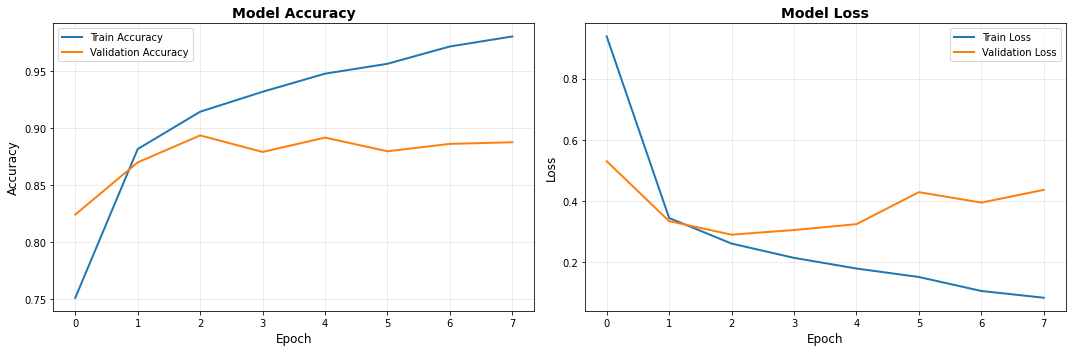

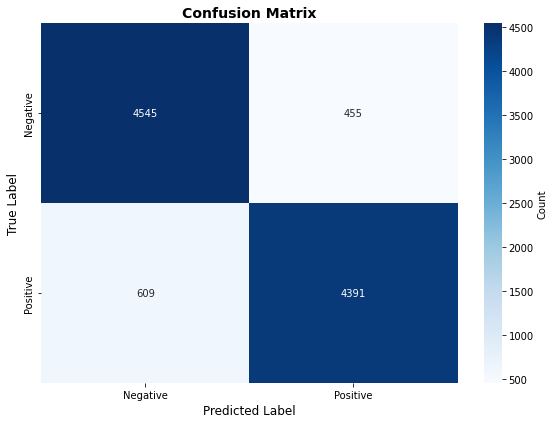

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
def predict_sentiment(text, model, tokenizer, max_length):
    """Predict sentiment for a given text"""
    # Preprocess
    processed = preprocess_text(text)
    # Tokenize
    sequence = tokenizer.texts_to_sequences([processed])
    # Pad
    padded = pad_sequences(sequence, maxlen=max_length, padding='post', truncating='post')
    # Predict
    prediction = model.predict(padded, verbose=0)[0][0]
    sentiment = 'Positive' if prediction > 0.5 else 'Negative'
    confidence = prediction if prediction > 0.5 else 1 - prediction

    return sentiment, confidence

# Test samples
test_reviews = [
    "This movie was absolutely fantastic! I loved every minute of it.",
    "Terrible waste of time. I hated this movie.",
    "It was okay, nothing special but not terrible either.",
    "An masterpiece of cinema! Brilliant acting and stunning visuals."
]

print("\nSample Predictions:")
print("=" * 80)
for review in test_reviews:
    sentiment, confidence = predict_sentiment(review, model, tokenizer, max_length)
    print(f"Review: {review}")
    print(f"Prediction: {sentiment} (Confidence: {confidence:.4f})")
    print("-" * 80)


Sample Predictions:
Review: This movie was absolutely fantastic! I loved every minute of it.
Prediction: Positive (Confidence: 0.9323)
--------------------------------------------------------------------------------
Review: Terrible waste of time. I hated this movie.
Prediction: Negative (Confidence: 0.9974)
--------------------------------------------------------------------------------
Review: It was okay, nothing special but not terrible either.
Prediction: Negative (Confidence: 0.9957)
--------------------------------------------------------------------------------
Review: An masterpiece of cinema! Brilliant acting and stunning visuals.
Prediction: Positive (Confidence: 0.9891)
--------------------------------------------------------------------------------


In [ ]:
model.save('improved_sentiment_model.keras')

# Save tokenizer
import pickle
with open('tokenizer.pickle', 'wb') as f:
    pickle.dump(tokenizer, f, protocol=pickle.HIGHEST_PROTOCOL)

print("\nTraining complete! Model and tokenizer saved.")
print(f"Final Test Accuracy: {accuracy:.4f}")
print(f"Final Test AUC-ROC: {auc_score:.4f}")


Training complete! Model and tokenizer saved.
Final Test Accuracy: 0.8936
Final Test AUC-ROC: 0.9594
